We clustered adverbs and adjectives based on feature vectors, where each value in the vector was a proportion of the lemmas having the property on that column. 
The question is now if we did the same using BERT embeddings - clustered all the lemmas based on their BERT embedding - would we get similar clusters?

In [1]:
# Import Required Libraries

# Importing the transformers library for BERT embeddings
from transformers import BertModel, BertTokenizer

# Importing the conllu library to parse the French conllu treebank
from conllu import parse

# Importing sklearn for clustering
from sklearn.cluster import KMeans

# Importing torch for tensor operations
import torch

In [2]:
treebanks_path = '/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master'
files_to_read = ['/fr_gsd-ud-train.conllu', '/fr_gsd-ud-dev.conllu', '/fr_gsd-ud-test.conllu']
data = ''
for file in files_to_read:
    with open(treebanks_path + file, 'r') as f:
        data += f.read()


parsed_data = parse(data)
print(parsed_data[0])

adv_lemmas = []
for sentence in parsed_data:
    for token in sentence:
        if token['upostag'] == 'ADV':
            adv_lemmas.append(token['lemma'])

# print(adv_lemmas)
# print(len(adv_lemmas))
# adv_lemmas = list(adv_lemmas)

TokenList<Les, commotions, cérébrales, sont, devenu, si, courantes, dans, ce, sport, qu', on, les, considére, presque, comme, la, routine, ., metadata={global.columns: "ID FORM LEMMA UPOS XPOS FEATS HEAD DEPREL DEPS MISC", sent_id: "fr-ud-train_00001", text: "Les commotions cérébrales sont devenu si courantes dans ce sport qu'on les considére presque comme la routine."}>


In [3]:
# remove the adverbs with less than 10 occurrences
print(len(adv_lemmas))
adv_lemmas = [item for item in adv_lemmas if adv_lemmas.count(item) > 10]
print(len(set(adv_lemmas)))
adv_lemmas = list(set(adv_lemmas))

14142
127


In [4]:

# Load pre-trained BERT model and tokenizer

model_name = 'bert-base-multilingual-uncased'
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertModel.from_pretrained(model_name)

# Function to generate BERT embeddings for a list of lemmas
def get_bert_embeddings(lemmas):
    embeddings = []
    for lemma in lemmas:
        # Tokenize the lemma
        inputs = tokenizer(lemma, return_tensors='pt')
        # Get the hidden states from BERT
        with torch.no_grad():
            outputs = model(**inputs)
        # Get the embeddings for the [CLS] token
        cls_embedding = outputs.last_hidden_state[:, 0, :].squeeze().numpy()
        embeddings.append(cls_embedding)
    return embeddings

# Generate embeddings for the adverb lemmas
adverb_embeddings = get_bert_embeddings(adv_lemmas)

# Display the shape of the embeddings to verify
print(f"Generated {len(adverb_embeddings)} embeddings with shape {adverb_embeddings[0].shape}")

Generated 127 embeddings with shape (768,)


In [5]:
import numpy as np
# turn list into numpy array
adverb_embeddings = np.array(adverb_embeddings)
print(adverb_embeddings.shape)
print(type(adv_lemmas))

(127, 768)
<class 'list'>


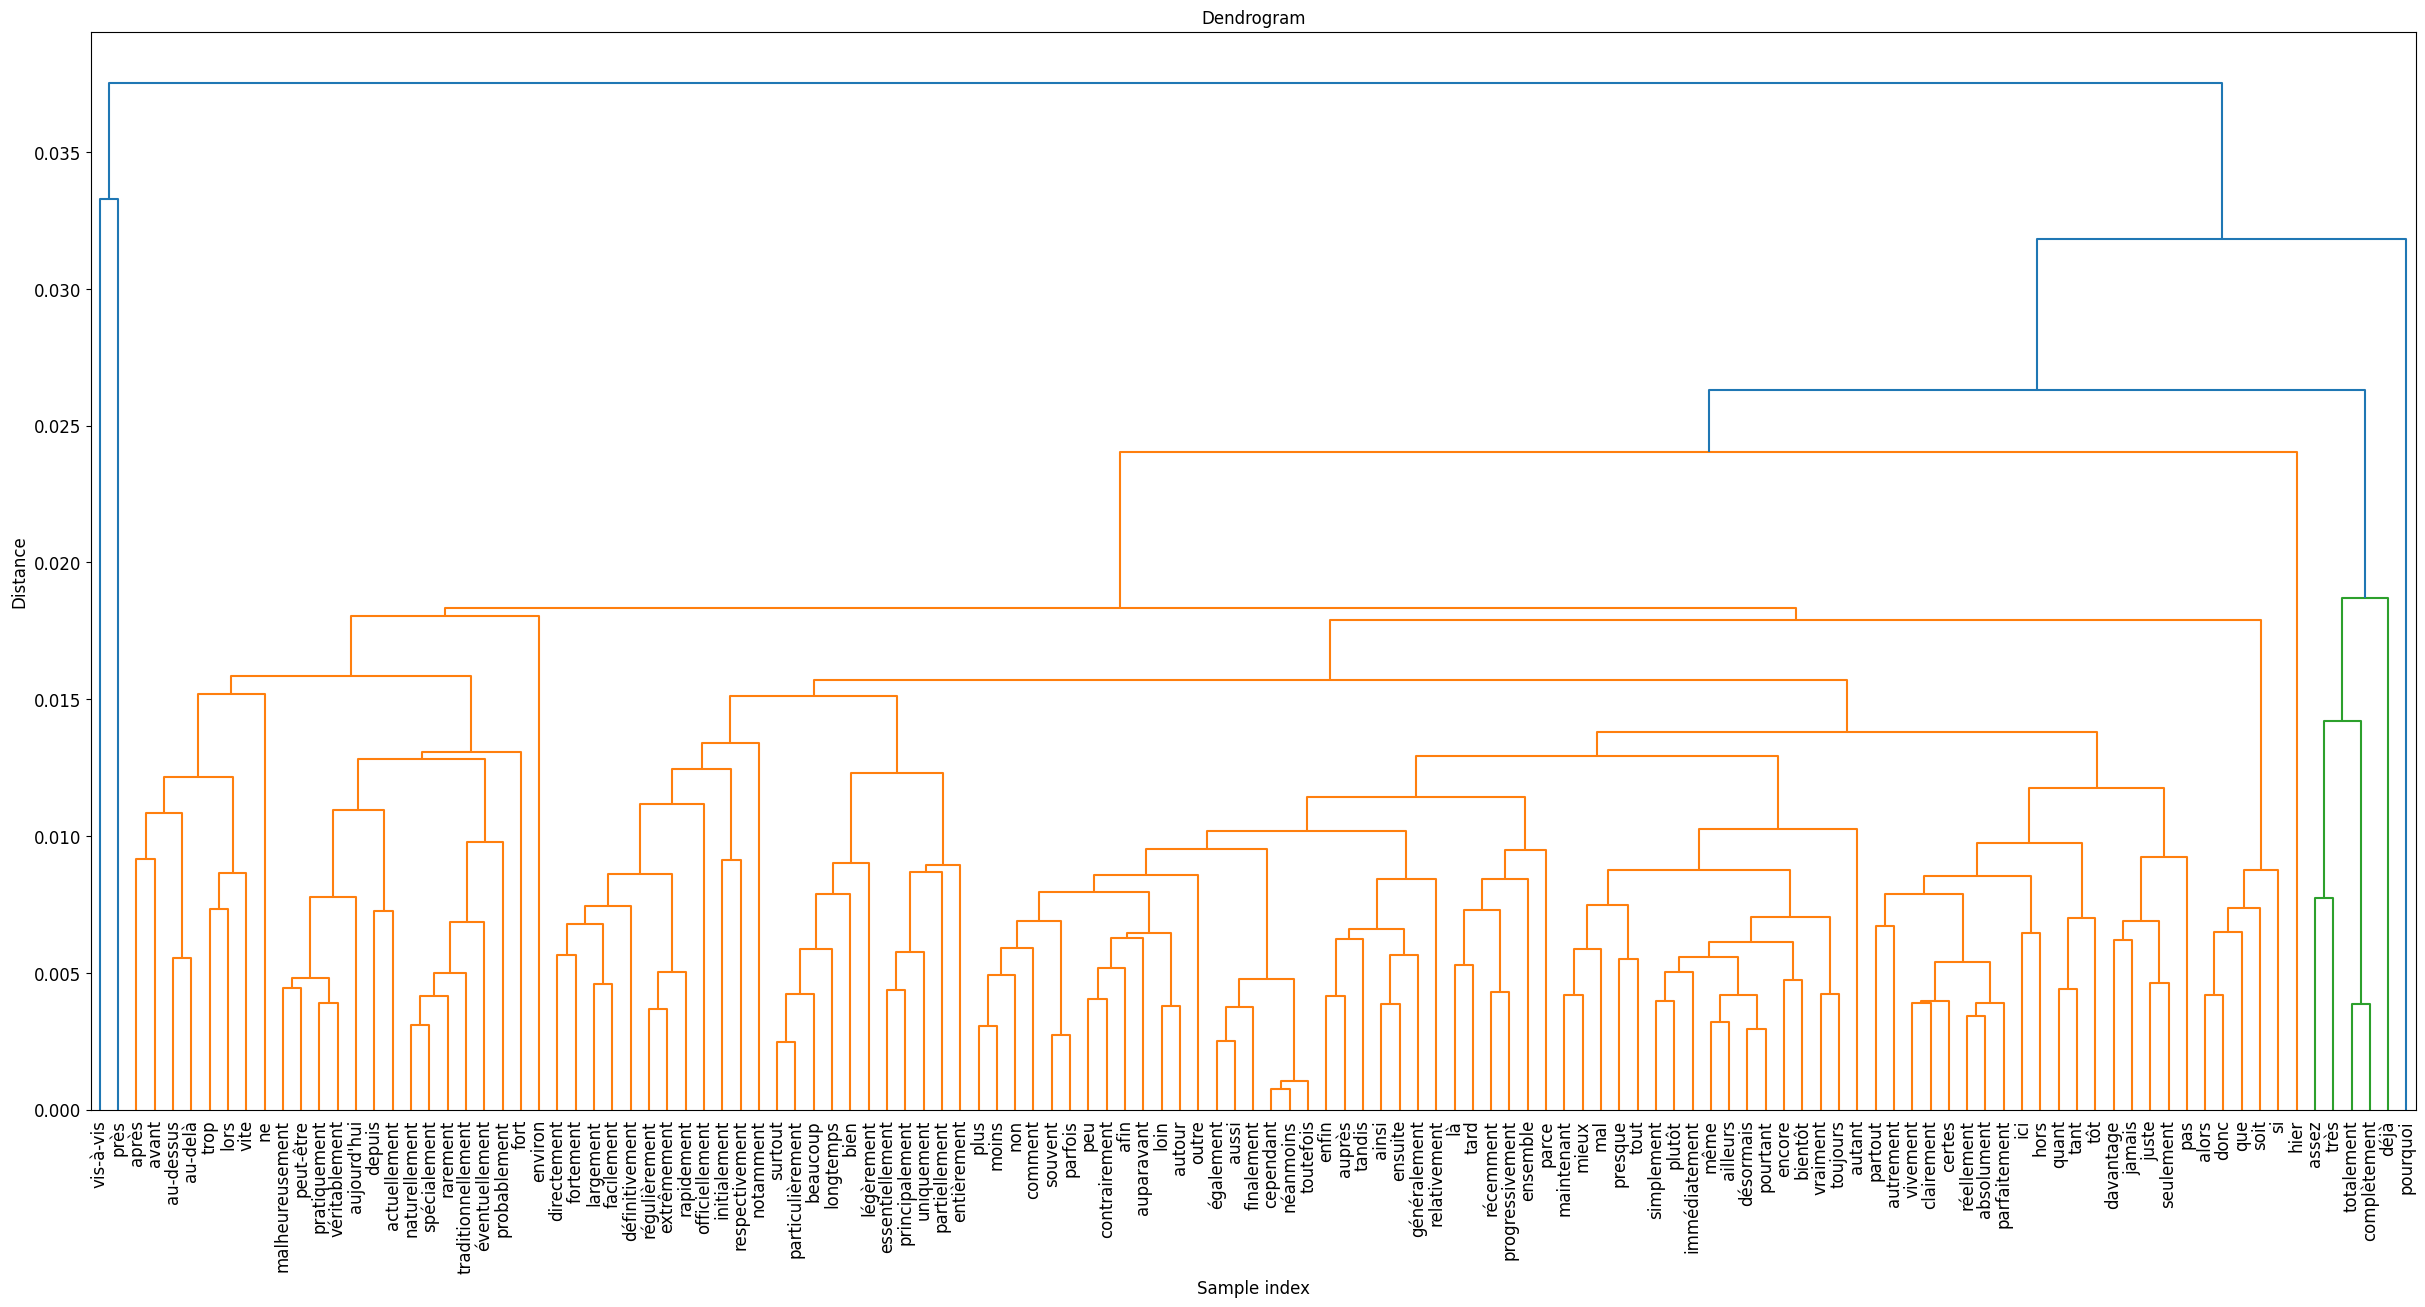

In [6]:
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, dendrogram, to_tree
import matplotlib.pyplot as plt

distance_matrix = pdist(adverb_embeddings, metric='cosine')
# Complete -> we cluster 
linked = linkage(distance_matrix, method="complete", optimal_ordering=True)

plt.figure(figsize=(30, 14))

dn = dendrogram(linked,
                orientation='top',
                labels=[name for name in adv_lemmas],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Dendrogram', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

In [7]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score

def find_optimal_clusters(X, max_clusters=20, metric='cosine', method='complete'):
    distance_matrix = pdist(X, metric=metric)
    linked = linkage(distance_matrix, method=method, optimal_ordering=True)
    
    silhouette_scores = []
    for num_clusters in range(2, max_clusters + 1):
        labels = fcluster(linked, num_clusters, criterion='maxclust')
        if len(np.unique(labels)) > 1:  # Ensure there is more than one cluster
            score = silhouette_score(X, labels, metric=metric)
            silhouette_scores.append(score)
            print(f'Number of clusters: {num_clusters}, Silhouette Score: {score}')
        else:
            silhouette_scores.append(-1)  # Append a low score if only one cluster
    
    optimal_clusters = np.argmax(silhouette_scores) + 2  # +2 because range starts from 2
    return optimal_clusters, silhouette_scores
optimal_clusters, silhouette_scores = find_optimal_clusters(adverb_embeddings, max_clusters=126)
print(f'Optimal number of clusters: {optimal_clusters}')
print(adverb_embeddings.shape)

Number of clusters: 2, Silhouette Score: 0.5507128238677979
Number of clusters: 3, Silhouette Score: 0.5313764214515686
Number of clusters: 4, Silhouette Score: 0.46014347672462463
Number of clusters: 5, Silhouette Score: 0.32026106119155884
Number of clusters: 6, Silhouette Score: 0.32265543937683105
Number of clusters: 7, Silhouette Score: 0.3014802038669586
Number of clusters: 8, Silhouette Score: 0.14199198782444
Number of clusters: 9, Silhouette Score: 0.1370190978050232
Number of clusters: 10, Silhouette Score: 0.1405567228794098
Number of clusters: 11, Silhouette Score: 0.13042648136615753
Number of clusters: 12, Silhouette Score: 0.09835486859083176
Number of clusters: 13, Silhouette Score: 0.09927156567573547
Number of clusters: 14, Silhouette Score: 0.08508966118097305
Number of clusters: 15, Silhouette Score: 0.09165246784687042
Number of clusters: 16, Silhouette Score: 0.07722768932580948
Number of clusters: 17, Silhouette Score: 0.07529990375041962
Number of clusters: 18, 

The problem with this approach is that I'm not really using transformes in the way they were meant to be used. When i am getting embeddings of lemmas isolated from their context i am getting rid of the strength of the transformer - its capacity to embed the context. 

So ideally we would get context based embeddings, the context being the sentence around the lemma.

In [8]:
treebanks_path = '/Users/madalina/Documents/M1TAL/stage-SK/Treebanks/UD_French-GSD-master'
files_to_read = ['/fr_gsd-ud-train.conllu', '/fr_gsd-ud-dev.conllu', '/fr_gsd-ud-test.conllu']
data = ''
for file in files_to_read:
    with open(treebanks_path + file, 'r') as f:
        data += f.read()


parsed_data = parse(data)
print(parsed_data[0])

adv_lemmas_sentences = [] # a list of tuples where the first element is the lemma of the adverb and the second element is the sentence the adverb is in
for sentence in parsed_data:
    for token in sentence:
        if token['upostag'] == 'ADV':
            adv_lemmas_sentences.append((token['lemma'], token['form'], sentence.metadata['text']))


print(len(adv_lemmas_sentences))
print(adv_lemmas_sentences[0])

TokenList<Les, commotions, cérébrales, sont, devenu, si, courantes, dans, ce, sport, qu', on, les, considére, presque, comme, la, routine, ., metadata={global.columns: "ID FORM LEMMA UPOS XPOS FEATS HEAD DEPREL DEPS MISC", sent_id: "fr-ud-train_00001", text: "Les commotions cérébrales sont devenu si courantes dans ce sport qu'on les considére presque comme la routine."}>
14142
('si', 'si', "Les commotions cérébrales sont devenu si courantes dans ce sport qu'on les considére presque comme la routine.")


In [9]:
all_adverbs = [item[0] for item in adv_lemmas_sentences]
print(len(all_adverbs))
for adv in all_adverbs:
    # check it appears at least 10 times
    if all_adverbs.count(adv) < 10:
        all_adverbs.remove(adv)
print(len(all_adverbs))
all_adverbs = list(set(all_adverbs))
print(len(all_adverbs))

14142
13240
206


In [10]:
for pair in adv_lemmas_sentences:
    if pair[0] not in all_adverbs:
        adv_lemmas_sentences.remove(pair)
print(len(adv_lemmas_sentences))

13423


In [11]:
test = [('vis-à-vis', 'vis-à-vis', "Le comportement de la Turquie vis-à-vis du problème palestinien a fait qu'elle n'est plus en odeur de sainteté auprès de la communauté juive en générale, et américaine en particulier."),
('ne', "n'", "Le comportement de la Turquie vis-à-vis du problème palestinien a fait qu'elle n'est plus en odeur de sainteté auprès de la communauté juive en générale, et américaine en particulier."),
('auprès', 'auprès', "Le comportement de la Turquie vis-à-vis du problème palestinien a fait qu'elle n'est plus en odeur de sainteté auprès de la communauté juive en générale, et américaine en particulier."),
('toutefois', 'Toutefois', 'Toutefois, les filles adorent les desserts.')]

In [12]:
def get_contextual_bert_embeddings(adv_lemmas_sentences):
    embeddings = {}
    for pair in adv_lemmas_sentences:
        # print(pair)
        # Tokenize the sentence
        inputs = tokenizer(pair[2], return_tensors='pt', truncation=True, padding=True)
        # Get the hidden states from BERT
        with torch.no_grad():
            outputs = model(**inputs)
        # Get the embeddings for the adverb in the sentence

        try:
            tokenized_sentence = tokenizer.convert_ids_to_tokens(inputs['input_ids'][0])
            # print(f"tokenized sentence: {tokenized_sentence}")
            adverb_tokens = tokenizer.tokenize(pair[1])
            # print(f"adverb tokens: {adverb_tokens}")
            start_index = tokenized_sentence.index(adverb_tokens[0])
            # print(f"start index: {start_index}")
            # print(f"indexes for adverb: {start_index, start_index + len(adverb_tokens)}")
            adverb_embeddings = outputs.last_hidden_state.squeeze(0)[start_index:start_index + len(adverb_tokens)].numpy()
            adverb_embedding = adverb_embeddings.mean(axis=0)
        except ValueError:
            print(pair)
            print(f"tokenized sentence: {tokenized_sentence}")
            print(f"adverb tokens: {adverb_tokens}")
            print(f"start index: {start_index}")
            print(f"indexes for adverb: {start_index, start_index + len(adverb_tokens)}")
            print(f"adverb embeddings: {adverb_embeddings}")
            print(f"adverb embedding: {adverb_embedding}")
            
            
        if pair[0] not in embeddings:
            embeddings[pair[0]] = [adverb_embedding]
        else:
            embeddings[pair[0]].append(adverb_embedding)
    return embeddings

contextual_adverb_embeddings = get_contextual_bert_embeddings(adv_lemmas_sentences)
# contextual_adverb_embeddings = get_contextual_bert_embeddings(test)

('au-dessus', 'à', "Les papillons sont visibles entre mai et juin dans les zones de faibles altitudes tandis qu'au dessus de 1 000 mètres, les papillons sont visibles vers le début juillet.")
tokenized sentence: ['[CLS]', 'les', 'pap', '##illon', '##s', 'sont', 'visibles', 'entre', 'mai', 'et', 'juin', 'dans', 'les', 'zones', 'de', 'faible', '##s', 'altitude', '##s', 'tandis', 'qu', "'", 'au', 'dessus', 'de', '1', '000', 'metres', ',', 'les', 'pap', '##illon', '##s', 'sont', 'visibles', 'vers', 'le', 'debut', 'juillet', '.', '[SEP]']
adverb tokens: ['a']
start index: 19
indexes for adverb: (19, 20)
adverb embeddings: [[-3.93074870e-01  1.65568367e-01 -6.65529728e-01  4.78234768e-01
  -4.72488925e-02  5.57722747e-01 -7.24582791e-01  4.64625955e-02
  -6.35912567e-02  1.92731414e-02  1.48035765e-01  2.22330391e-01
  -1.48817822e-02 -1.37596637e-01  3.29898953e-01 -5.92165887e-01
   4.94154990e-02 -2.18339071e-01  7.58591481e-03 -4.74834442e-01
   3.19857657e-01  2.01835081e-01  4.69336271

In [13]:
original_contextual_adverb_embeddings = contextual_adverb_embeddings.copy()

In [14]:
# contextual_adverb_embeddings = original_contextual_adverb_embeddings.copy()
# print(contextual_adverb_embeddings.keys())
# for those that have more embeddings than 1, we average them
for key, value in contextual_adverb_embeddings.items():
    if len(value) > 1:
        contextual_adverb_embeddings[key] = np.array(value).mean(axis=0)
    else:
        contextual_adverb_embeddings[key] = value[0]
print(contextual_adverb_embeddings.keys())

dict_keys(['si', 'presque', 'vis-à-vis', 'ne', 'plus', 'auprès', 'toutefois', 'autour', 'ensuite', 'pas', 'ailleurs', "aujourd'hui", 'tard', 'beaucoup', 'alors', 'déjà', 'même', 'environ', 'soit', 'encore', 'donc', 'également', 'suffisamment', 'tout', 'toujours', 'très', 'bien', 'que', 'plutôt', 'évidemment', 'longtemps', 'cependant', 'quasi', 'actuellement', 'notamment', 'moins', 'mieux', 'lors', 'aussi', 'peu', 'seulement', 'là', 'parfois', 'peut-être', 'afin', 'simplement', 'traditionnellement', 'au-delà', 'ainsi', 'officiellement', 'constamment', 'quelque', 'probablement', 'auparavant', 'non', 'pratiquement', 'tant', 'au-dessus', 'autant', 'près', 'naturellement', 'ci-dessous', 'après', 'totalement', 'surtout', 'maintenant', 'ici', 'correctement', 'principalement', 'respectivement', 'souvent', 'forcément', 'loin', 'tandis', 'faute', 'largement', 'jamais', 'assez', 'rapidement', 'explicitement', 'désormais', 'pourtant', 'parce', 'avant', 'trop', 'hors', 'ensemble', 'normalement', 'r

In [15]:
X = np.array(list(contextual_adverb_embeddings.values()))
print(X.shape)

(206, 768)


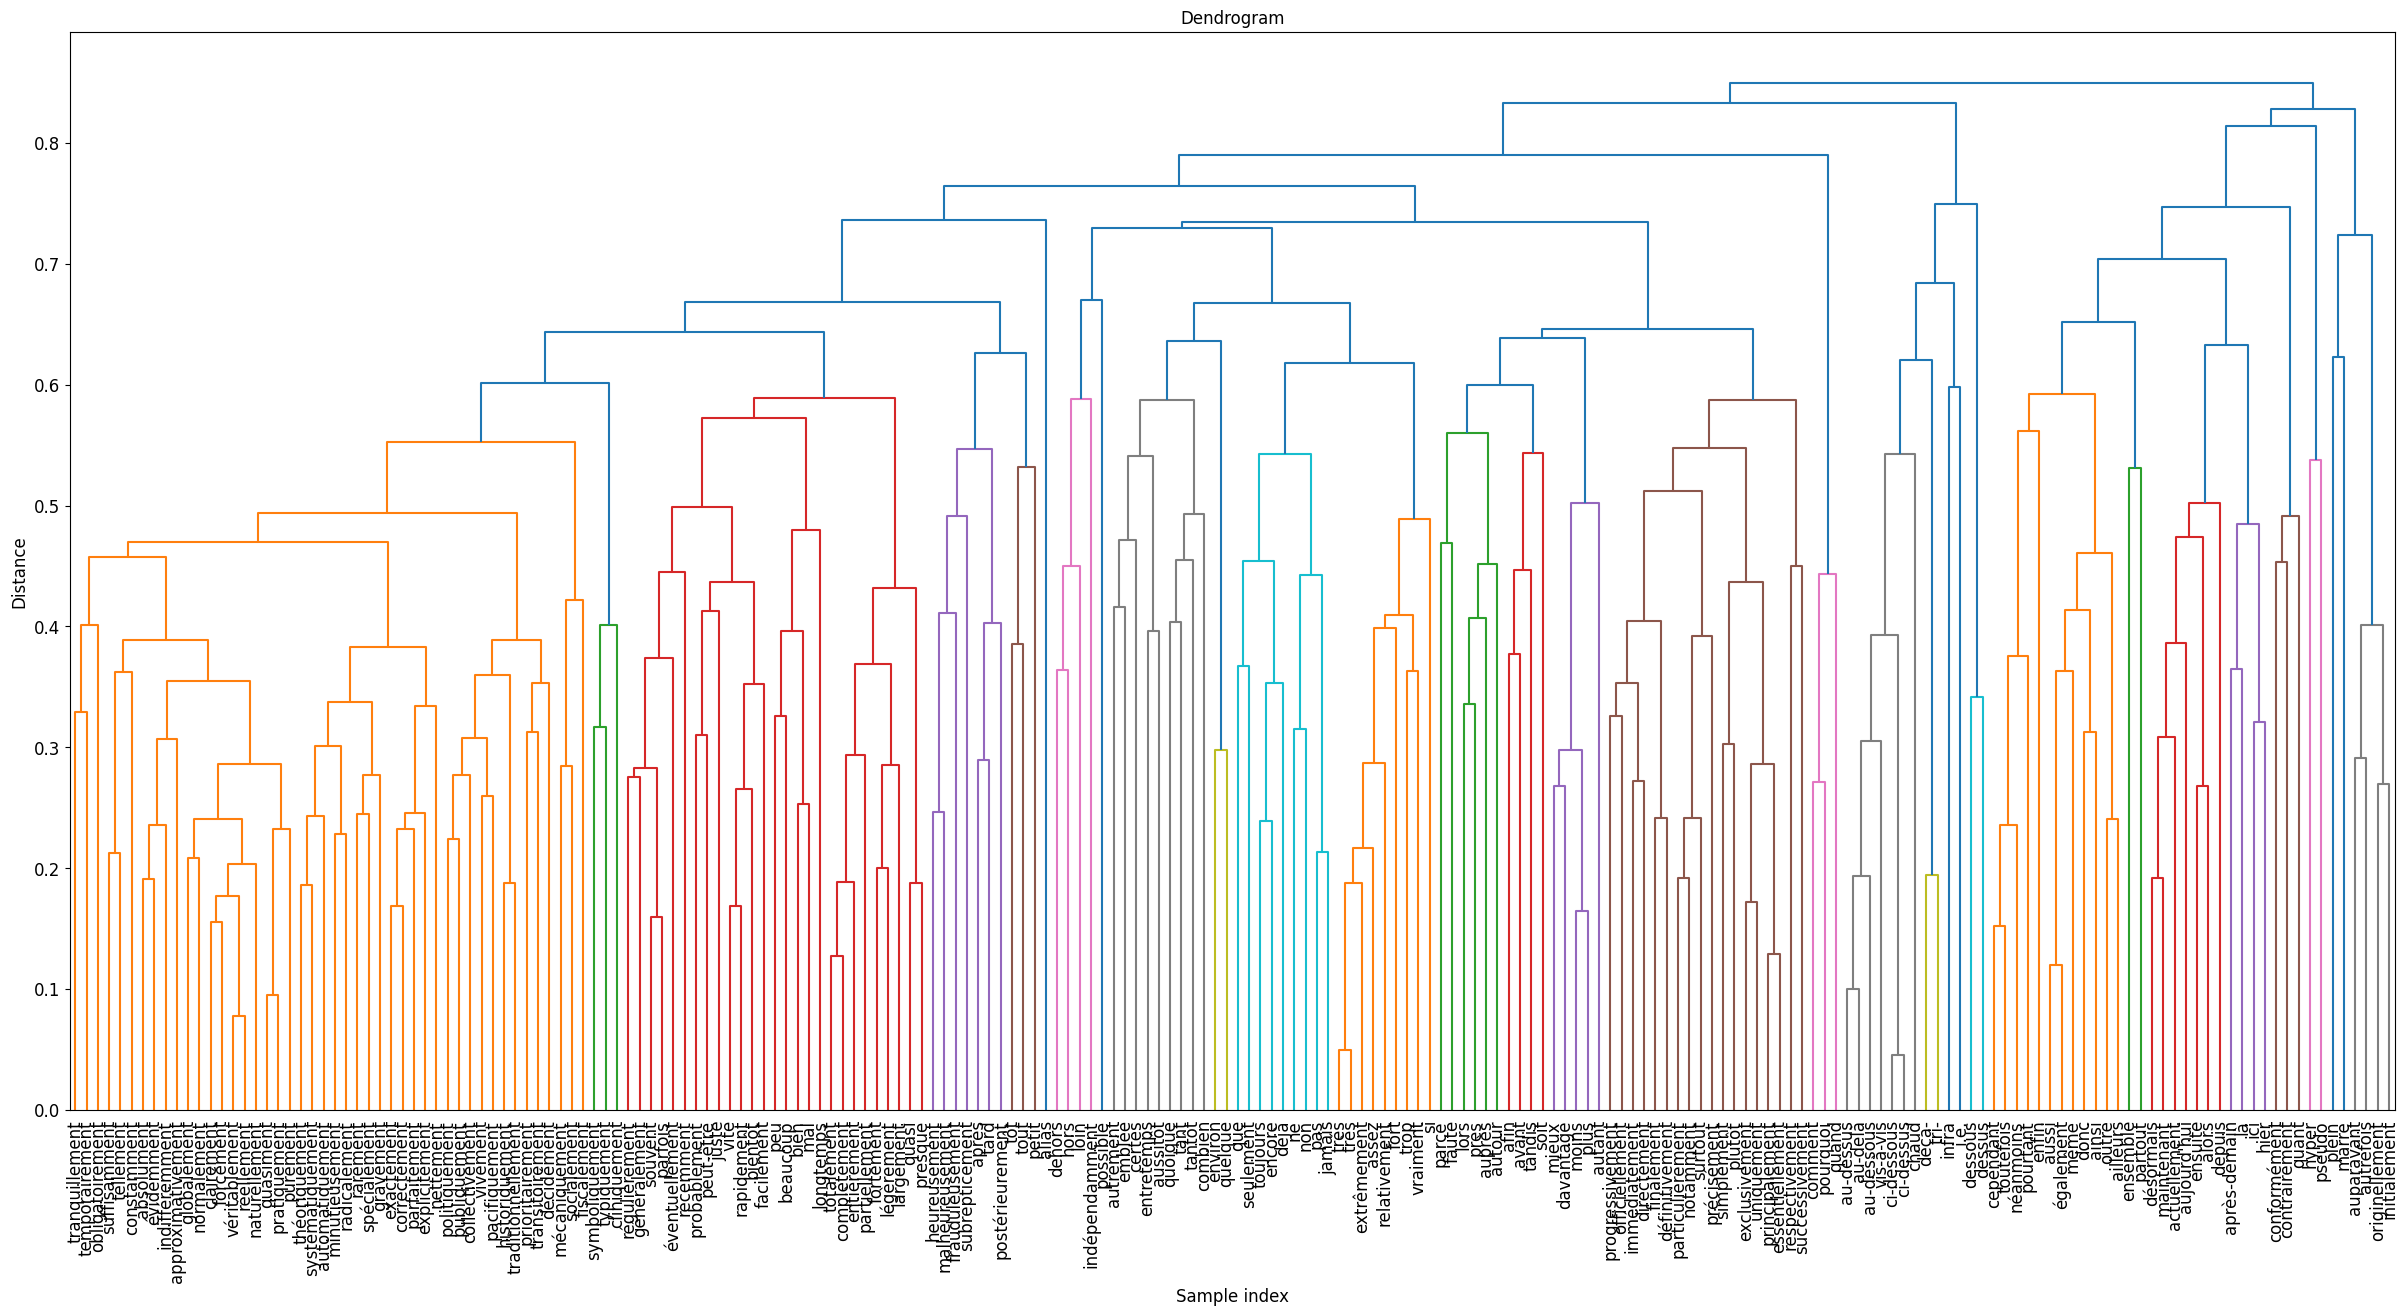

In [16]:
#make clustering with dendrogram and pdist
# print(contextual_adverb_embeddings.shape)
distance_matrix = pdist(X, metric='cosine')
# Complete -> we cluster
linked = linkage(distance_matrix, method="complete", optimal_ordering=True)

plt.figure(figsize=(30, 14))

dn = dendrogram(linked,
                orientation='top',
                labels=[name for name in contextual_adverb_embeddings.keys()],
                distance_sort='descending',
                show_leaf_counts=True,
                get_leaves=True)

plt.title('Dendrogram', fontsize=12)  # Increase title font size
plt.xlabel('Sample index', fontsize=12)  # Increase x-axis label font size
plt.ylabel('Distance', fontsize=12)  # Increase y-axis label font size
plt.xticks(fontsize=12)  # Increase x-tick labels font size
plt.yticks(fontsize=12)  # Increase y-tick labels font size
plt.show()

In [17]:
import numpy as np
from scipy.spatial.distance import pdist
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score

def find_optimal_clusters(X, max_clusters=20, metric='cosine', method='complete'):
    distance_matrix = pdist(X, metric=metric)
    linked = linkage(distance_matrix, method=method, optimal_ordering=True)
    
    silhouette_scores = []
    for num_clusters in range(2, max_clusters + 1):
        labels = fcluster(linked, num_clusters, criterion='maxclust')
        if len(np.unique(labels)) > 1:  # Ensure there is more than one cluster
            score = silhouette_score(X, labels, metric=metric)
            silhouette_scores.append(score)
            print(f'Number of clusters: {num_clusters}, Silhouette Score: {score}')
        else:
            silhouette_scores.append(-1)  # Append a low score if only one cluster
    
    optimal_clusters = np.argmax(silhouette_scores) + 2  # +2 because range starts from 2
    return optimal_clusters, silhouette_scores
optimal_clusters, silhouette_scores = find_optimal_clusters(X, max_clusters=205)
print(f'Optimal number of clusters: {optimal_clusters}')
print(X.shape)

Number of clusters: 2, Silhouette Score: 0.12065503001213074
Number of clusters: 3, Silhouette Score: 0.10616163909435272
Number of clusters: 4, Silhouette Score: 0.10722634196281433
Number of clusters: 5, Silhouette Score: 0.10736717283725739
Number of clusters: 6, Silhouette Score: 0.11568676680326462
Number of clusters: 7, Silhouette Score: 0.08667623996734619
Number of clusters: 8, Silhouette Score: 0.08877886831760406
Number of clusters: 9, Silhouette Score: 0.09302414953708649
Number of clusters: 10, Silhouette Score: 0.09388928860425949
Number of clusters: 11, Silhouette Score: 0.09630875289440155
Number of clusters: 12, Silhouette Score: 0.09739869087934494
Number of clusters: 13, Silhouette Score: 0.09826093167066574
Number of clusters: 14, Silhouette Score: 0.10112763941287994
Number of clusters: 15, Silhouette Score: 0.1007205992937088
Number of clusters: 16, Silhouette Score: 0.10145361721515656
Number of clusters: 17, Silhouette Score: 0.09610381722450256
Number of cluster

In [22]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

In [24]:
# see what there is in each cluster
distance_matrix = pdist(X, metric='cosine')
# Complete -> we cluster 
linked = linkage(distance_matrix, method="complete", optimal_ordering=True)
labels = fcluster(linked, optimal_clusters, criterion='maxclust')
clusters = {i: [] for i in range(1, optimal_clusters + 1)}
for i, label in enumerate(labels):
    clusters[label].append(i)

In [26]:
import plotly.graph_objects as go
import pandas as pd

# Create a DataFrame for Plotly
df = pd.DataFrame({
    'PCA1': X_tsne[:, 0],
    'PCA2': X_tsne[:, 1],
    'Cluster': labels,
    'Word': contextual_adverb_embeddings.keys()
})
# pca1_min, pca1_max = df['PCA1'].min(), df['PCA1'].max()
# pca2_min, pca2_max = df['PCA2'].min(), df['PCA2'].max()
# Create a scatter plot with Plotly
fig = go.Figure()

# Add traces for each cluster
for cluster in range(1, optimal_clusters + 1):
    cluster_data = df[df['Cluster'] == cluster]
    fig.add_trace(go.Scatter(
        x=cluster_data['PCA1'],
        y=cluster_data['PCA2'],
        mode='markers',
        marker=dict(size=10),
        name=f'Cluster {cluster}',
        text=cluster_data['Word'],
        hovertemplate='%{text}<extra></extra>',
    ))

# Update layout with dropdown menu
fig.update_layout(
    title='Word Clusters',
    xaxis_title='tsne1',
    yaxis_title='tsne2',
    width=1600,  # Set the width of the figure
    height=800,  # Set the height of the figure
    # xaxis=dict(range=[pca1_min, pca1_max]),
    # yaxis=dict(range=[pca2_min, pca2_max]),
    updatemenus=[
        {
            'buttons': [
                {
                    'label': 'All Clusters',
                    'method': 'update',
                    'args': [{'visible': [True] * optimal_clusters},
                             {'title': 'All Clusters'}]
                }
            ] + [
                {
                    'label': f'Cluster {i}',
                    'method': 'update',
                    'args': [{'visible': [j == i - 1 for j in range(optimal_clusters)]},
                             {'title': f'Cluster {i}'}]
                } for i in range(1, optimal_clusters + 1)
            ],
            'direction': 'down',
            'showactive': True
        }
    ]
)

fig.show()

In [27]:
fig.write_html("/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/data/output/visualisations/BERT_adverbs_french_tsne.html")

So when looking at context BERT embeddings lead to clusters that are fairly similar and not well separated. this oculd come from me avergaging the embeddings over different occurrences of the lemmas so dilluting the differences between them. maybe i'm better off not doing that? but then it's very hard to read the results - 14000 lemmas is impossible to visualise.

In [21]:
from jumpsmethod import JumpsMethod
jm = JumpsMethod(X)
jm.distortions()
jm.jumps()
number_clusters = jm.number_clusters()
print(number_clusters)

/opt/homebrew/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/homebrew/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/homebrew/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/homebrew/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/opt/homebrew/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of

2


/opt/homebrew/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning:

The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning

/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/5. bert_clustering/jumpsmethod.py:71: RuntimeWarning:

overflow encountered in power

/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/5. bert_clustering/jumpsmethod.py:72: RuntimeWarning:

overflow encountered in power

/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/5. bert_clustering/jumpsmethod.py:73: RuntimeWarning:

overflow encountered in power

/Users/madalina/Documents/M2TAL/stage/check_coherent_labels/scripts/5. bert_clustering/jumpsmethod.py:72: RuntimeWarning:

invalid value encountered in scalar subtract

